# Ponds.csv — Extensive Descriptive Statistics

Dataset: `data/kaggle/Ponds.csv`  
3 stations, sub-daily (20-min) readings, Jan–Dec 2022.  
Variables: NITRATE, PH, AMMONIA, TEMP, DO, TURBIDITY, MANGANESE.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/kaggle/Ponds.csv'
DO_THRESHOLD = 3.0  # mg/L — hypoxia threshold used in welfare model

## 1. Load & parse

In [ ]:
df = pd.read_csv(DATA_PATH)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True)
df = df.sort_values(['Station', 'Date']).reset_index(drop=True)

# Derived time columns
df['date_only'] = df['Date'].dt.normalize()
df['month']     = df['Date'].dt.month
df['month_name']= df['Date'].dt.strftime('%b')
df['hour']      = df['Date'].dt.hour
df['dow']       = df['Date'].dt.day_name()
df['week']      = df['Date'].dt.isocalendar().week.astype(int)

# Hypoxia flag
df['low_DO'] = (df['DO'] < DO_THRESHOLD).astype(int)

SENSORS = ['NITRATE(PPM)', 'PH', 'AMMONIA(mg/l)', 'TEMP', 'DO', 'TURBIDITY', 'MANGANESE(mg/l)']
print(f"Shape: {df.shape}")
df.head(3)

Shape: (18102, 16)


,Station,Date,NITRATE(PPM),PH,AMMONIA(mg/l),TEMP,DO,TURBIDITY,MANGANESE(mg/l),date_only,month,month_name,hour,dow,week,low_DO
0,station1,2022-02-01 08:00:00,18.3,5.7,0.0,17.69,11.6,86.1,0.71,2022-02-01,2,Feb,8,Tuesday,5,0
1,station1,2022-02-01 08:20:00,3.6,5.1,0.0,19.42,10.5,71.8,0.62,2022-02-01,2,Feb,8,Tuesday,5,0
2,station1,2022-02-01 08:40:00,13.1,5.5,0.0,18.60,10.3,75.9,0.73,2022-02-01,2,Feb,8,Tuesday,5,0


## 2. Dataset overview

In [3]:
print("=== Stations ===")
print(df['Station'].value_counts())
print(f"\nDate range: {df['Date'].min()}  →  {df['Date'].max()}")
print(f"Span: {(df['Date'].max()-df['Date'].min()).days} days")
print(f"\nTotal readings: {len(df):,}")

# Reading interval check
diffs = df.groupby('Station')['Date'].diff().dt.total_seconds().div(60).dropna()
print(f"\nReading interval (minutes) — most common: {diffs.mode()[0]:.0f}")
print(diffs.describe().round(1))

=== Stations ===
Station
station1    6249
station2    6249
station3    5604
Name: count, dtype: int64

Date range: 2022-02-01 08:00:00  →  2022-04-29 02:39:00
Span: 86 days

Total readings: 18,102

Reading interval (minutes) — most common: 20
count    18099.0
mean        20.0
std          0.0
min         19.0
25%         20.0
50%         20.0
75%         20.0
max         20.0
Name: Date, dtype: float64


In [4]:
print("=== Missing values ===")
miss = df[SENSORS].isnull().sum()
miss_pct = (df[SENSORS].isnull().mean()*100).round(2)
pd.DataFrame({'missing_count': miss, 'missing_%': miss_pct})

=== Missing values ===


,missing_count,missing_%
NITRATE(PPM),26,0.14
PH,36,0.20
AMMONIA(mg/l),30,0.17
TEMP,41,0.23
DO,26,0.14
TURBIDITY,26,0.14
MANGANESE(mg/l),19,0.10


## 3. Global summary statistics

In [5]:
summary = df[SENSORS].describe(percentiles=[.05,.1,.25,.5,.75,.9,.95]).T.round(3)
summary['skew']     = df[SENSORS].skew().round(3)
summary['kurtosis'] = df[SENSORS].kurtosis().round(3)
summary['CV%']      = (df[SENSORS].std() / df[SENSORS].mean() * 100).round(1)
summary

,count,mean,std,min,5%,10%,25%,50%,75%,90%,95%,max,skew,kurtosis,CV%
NITRATE(PPM),18076.0,52.709,34.858,0.0,4.50,9.10,22.60,48.20,81.700,102.65,112.80,140.0,0.322,-1.037,66.1
PH,18066.0,6.863,1.440,0.0,5.10,5.20,5.60,6.50,8.100,9.00,9.50,10.0,0.478,-0.966,21.0
AMMONIA(mg/l),18072.0,0.385,0.376,0.0,0.00,0.00,0.10,0.30,0.700,0.90,1.00,2.0,1.030,0.973,97.9
TEMP,18061.0,25.370,8.212,0.0,15.44,16.07,17.89,23.81,32.450,37.81,39.69,42.0,0.421,-1.182,32.4
DO,18076.0,5.323,2.456,0.0,1.30,1.80,3.20,5.60,7.400,8.20,8.50,12.0,-0.133,-0.933,46.1
TURBIDITY,18076.0,137.897,91.645,0.5,11.60,23.30,58.70,125.30,213.525,269.50,288.30,398.9,0.347,-0.947,66.5
MANGANESE(mg/l),18083.0,1.123,0.514,0.6,0.61,0.63,0.69,0.93,1.510,1.84,1.95,3.5,1.131,1.447,45.8


## 4. Per-station summary

In [6]:
station_stats = df.groupby('Station')[SENSORS].agg(['mean','median','std','min','max'])
station_stats.round(2)

NITRATE(PPM)                              PH                          \
                 mean median    std  min    max  mean median   std  min   max   
Station                                                                         
station1        32.94   23.6  32.40  0.0  140.0  5.92    5.7  0.93  5.0   8.9   
station2        54.47   50.4  35.42  0.0  120.0  6.94    6.5  1.55  5.0  10.0   
station3        72.85   72.6  22.58  0.0  120.0  7.83    7.8  1.07  0.0  10.0   

          ... TURBIDITY                             MANGANESE(mg/l)         \
          ...      mean  median    std   min    max            mean median   
Station   ...                                                                
station1  ...     87.61   62.40  87.81   0.5  398.9            0.88   0.70   
station2  ...    136.37  125.25  89.09   0.5  300.0            1.11   0.94   
station3  ...    195.88  196.00  59.10  91.0  300.0            1.42   1.42   

                          
           std  min  max  
Station                   
station1  0.55  0.6  3.5  
station2  0.46  0.6  2.0  
station3  0.35  0.8  2.0  

[3 rows x 35 columns]

In [7]:
# Kruskal-Wallis test: do stations differ significantly for each sensor?
print("Kruskal-Wallis H-test (station differences)\n")
groups = [g[col].dropna().values for _, g in df.groupby('Station') for col in []][0:0]  # placeholder
for col in SENSORS:
    grps = [g[col].dropna().values for _, g in df.groupby('Station')]
    h, p = stats.kruskal(*grps)
    sig = '***' if p < 0.001 else ('**' if p < 0.01 else ('*' if p < 0.05 else 'ns'))
    print(f"  {col:<22}  H={h:8.1f}  p={p:.2e}  {sig}")

Kruskal-Wallis H-test (station differences)

  NITRATE(PPM)            H=  4525.4  p=0.00e+00  ***
  PH                      H=  5697.3  p=0.00e+00  ***
  AMMONIA(mg/l)           H=  5174.1  p=0.00e+00  ***
  TEMP                    H=  5362.6  p=0.00e+00  ***
  DO                      H=  5024.8  p=0.00e+00  ***
  TURBIDITY               H=  4858.7  p=0.00e+00  ***
  MANGANESE(mg/l)         H=  5445.2  p=0.00e+00  ***


## 5. Distributions — histograms & KDE

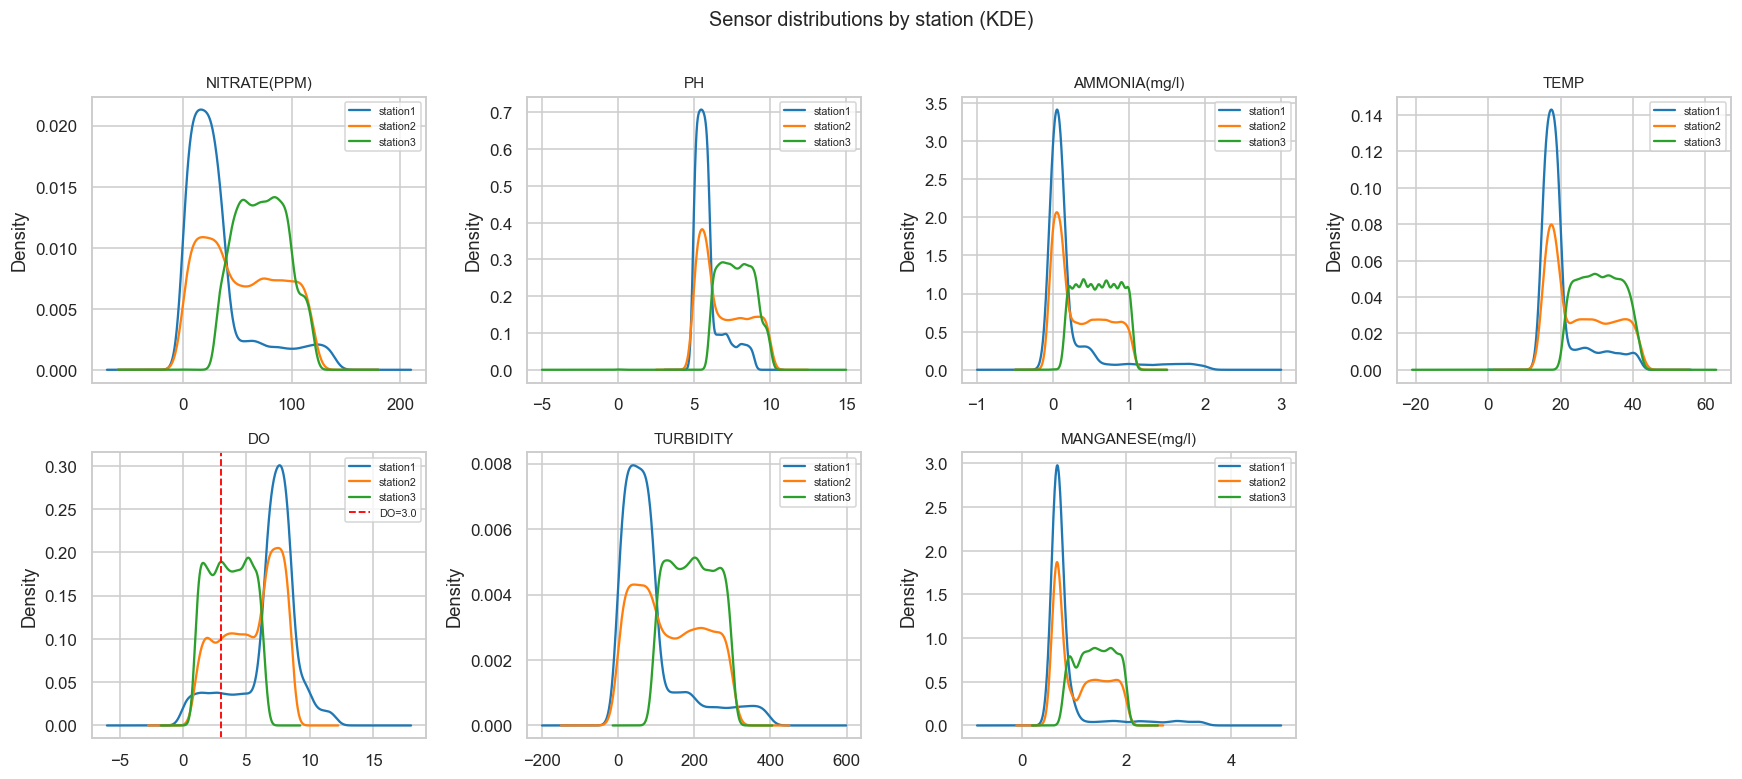

In [8]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(SENSORS):
    ax = axes[i]
    for stn, grp in df.groupby('Station'):
        grp[col].dropna().plot.kde(ax=ax, label=stn, linewidth=1.5)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
    ax.legend(fontsize=7)
# DO threshold line
axes[SENSORS.index('DO')].axvline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'DO={DO_THRESHOLD}')
axes[SENSORS.index('DO')].legend(fontsize=7)
axes[-1].set_visible(False)
fig.suptitle('Sensor distributions by station (KDE)', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

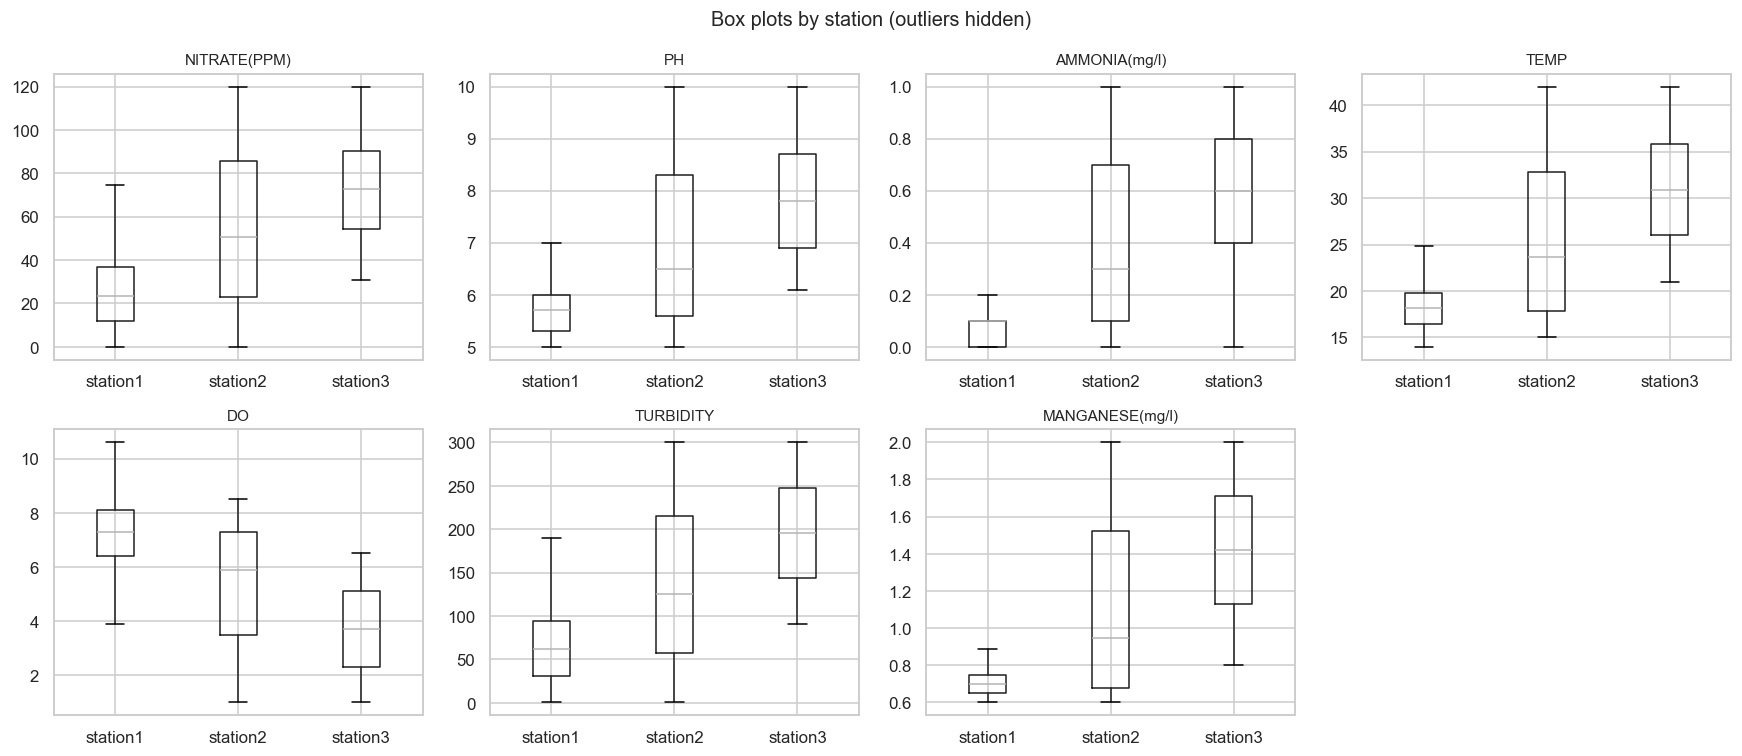

In [9]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
for i, col in enumerate(SENSORS):
    ax = axes[i]
    df.boxplot(column=col, by='Station', ax=ax, showfliers=False)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.suptitle('Box plots by station (outliers hidden)', fontsize=13)
axes[-1].set_visible(False)
plt.tight_layout()
plt.show()

## 6. Temporal patterns

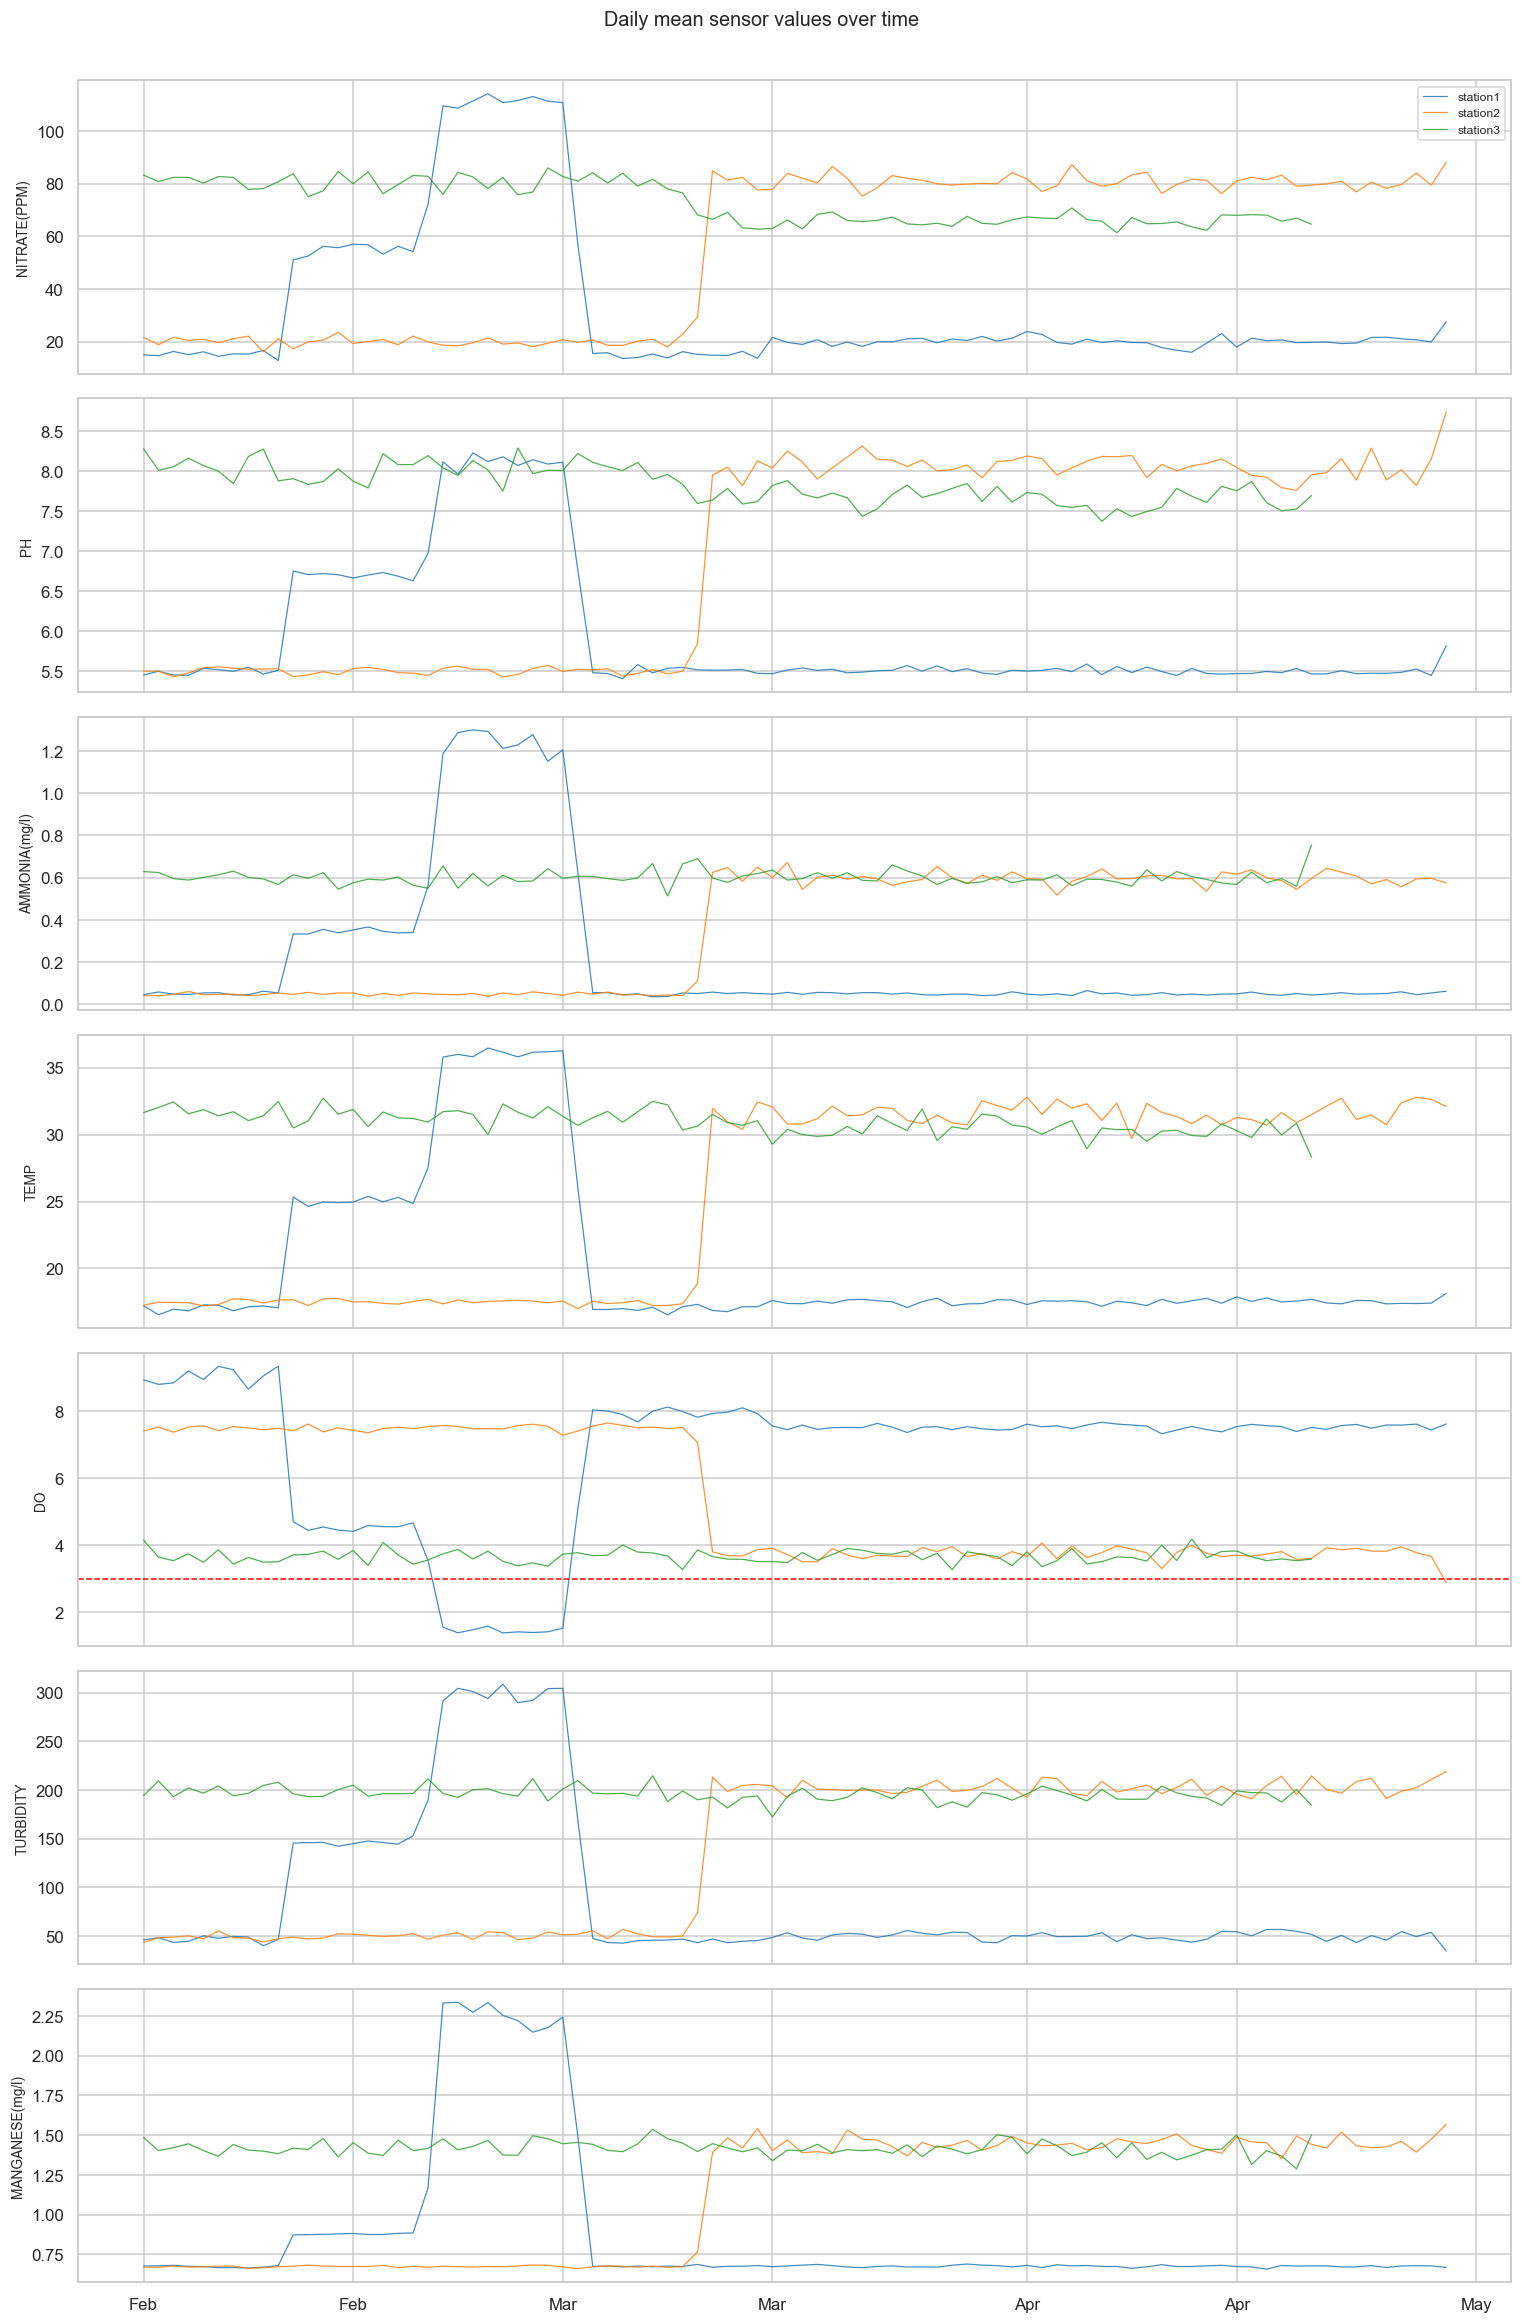

In [10]:
# Daily means per station
daily = df.groupby(['Station','date_only'])[SENSORS].mean().reset_index()

fig, axes = plt.subplots(len(SENSORS), 1, figsize=(14, 3*len(SENSORS)), sharex=True)
for ax, col in zip(axes, SENSORS):
    for stn, grp in daily.groupby('Station'):
        ax.plot(grp['date_only'], grp[col], linewidth=0.8, label=stn, alpha=0.85)
    ax.set_ylabel(col, fontsize=9)
    if col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1)
axes[0].legend(fontsize=8)
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%b'))
fig.suptitle('Daily mean sensor values over time', fontsize=13, y=1.005)
plt.tight_layout()
plt.show()

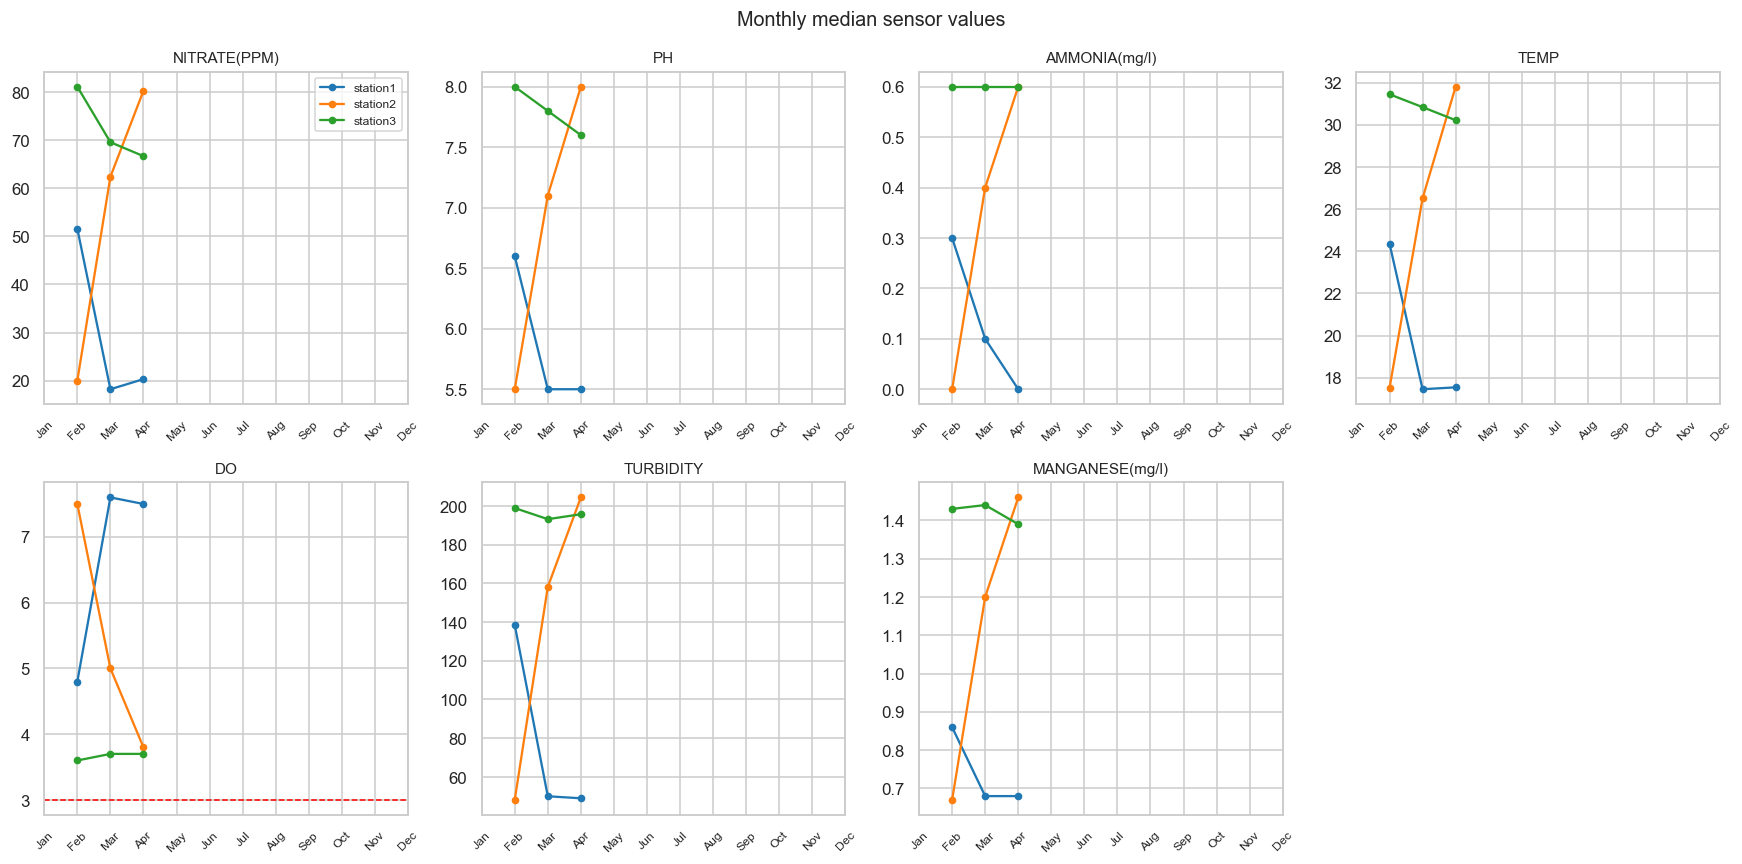

In [11]:
# Monthly medians
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
monthly = df.groupby(['month_name','Station'])[SENSORS].median().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(SENSORS):
    ax = axes[i]
    for stn, grp in monthly.groupby('Station'):
        grp_sorted = grp.set_index('month_name').reindex(MONTH_ORDER)
        ax.plot(range(len(MONTH_ORDER)), grp_sorted[col], marker='o', markersize=4, label=stn)
    ax.set_xticks(range(len(MONTH_ORDER)))
    ax.set_xticklabels(MONTH_ORDER, rotation=45, fontsize=8)
    ax.set_title(col, fontsize=10)
    if col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1)
axes[0].legend(fontsize=8)
axes[-1].set_visible(False)
fig.suptitle('Monthly median sensor values', fontsize=13)
plt.tight_layout()
plt.show()

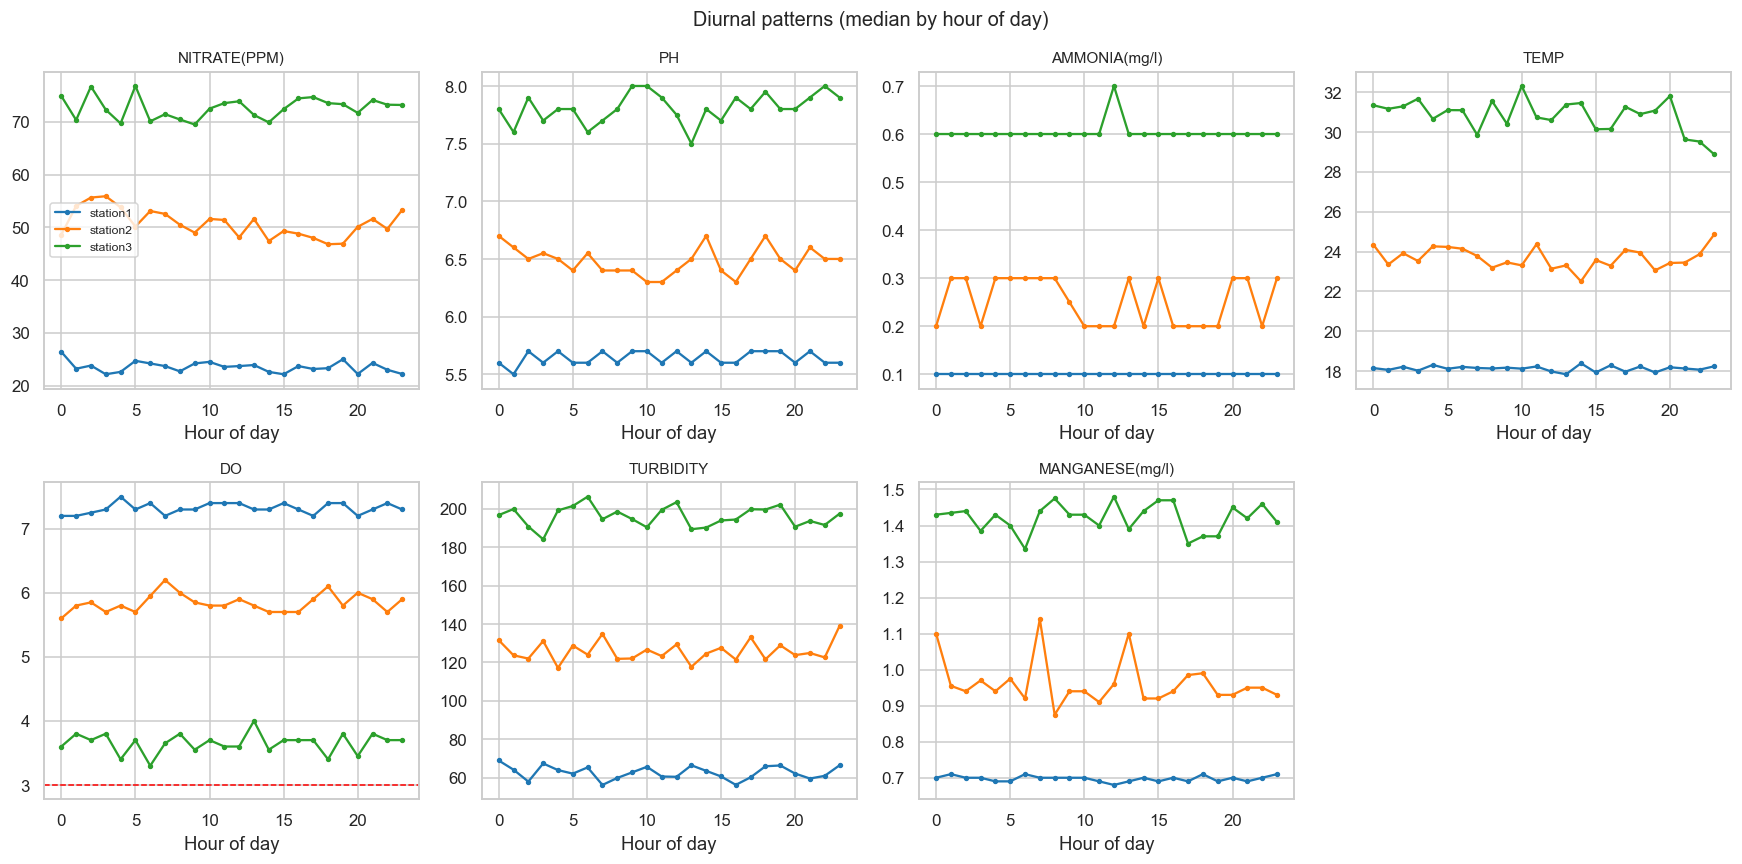

In [12]:
# Diurnal (hour-of-day) patterns
hourly = df.groupby(['hour','Station'])[SENSORS].median().reset_index()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()
for i, col in enumerate(SENSORS):
    ax = axes[i]
    for stn, grp in hourly.groupby('Station'):
        ax.plot(grp['hour'], grp[col], marker='.', markersize=5, label=stn)
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('Hour of day')
    if col == 'DO':
        ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1)
axes[0].legend(fontsize=8)
axes[-1].set_visible(False)
fig.suptitle('Diurnal patterns (median by hour of day)', fontsize=13)
plt.tight_layout()
plt.show()

## 7. Dissolved Oxygen (DO) deep-dive

In [13]:
# Prevalence of low-DO events
print(f"Readings with DO < {DO_THRESHOLD} mg/L (hypoxia):")
lo = df.groupby('Station')['low_DO'].agg(['sum','mean']).rename(columns={'sum':'count','mean':'fraction'})
lo['fraction_%'] = (lo['fraction']*100).round(1)
print(lo)
print(f"\nOverall: {df['low_DO'].sum():,} readings ({df['low_DO'].mean()*100:.1f}%)")

Readings with DO < 3.0 mg/L (hypoxia):
          count  fraction  fraction_%
Station                              
station1    700  0.112018        11.2
station2   1218  0.194911        19.5
station3   2057  0.367059        36.7

Overall: 3,975 readings (22.0%)


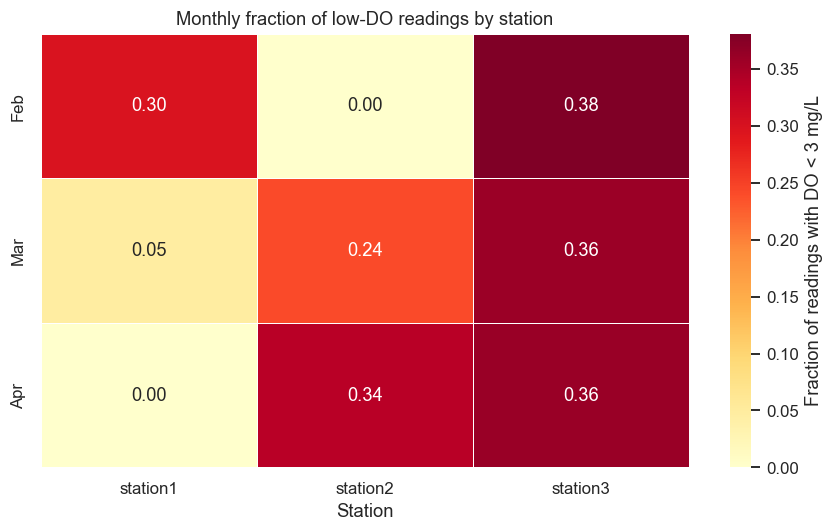

In [14]:
# Monthly low-DO fraction per station — heatmap
monthly_ldo = df.groupby(['month','month_name','Station'])['low_DO'].mean().reset_index()
pivot = monthly_ldo.pivot(index='month_name', columns='Station', values='low_DO')
month_order = [m for m in ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec'] if m in pivot.index]
pivot = pivot.reindex(month_order)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5, ax=ax,
            cbar_kws={'label':'Fraction of readings with DO < 3 mg/L'})
ax.set_title('Monthly fraction of low-DO readings by station', fontsize=12)
ax.set_ylabel('')
plt.tight_layout()
plt.show()

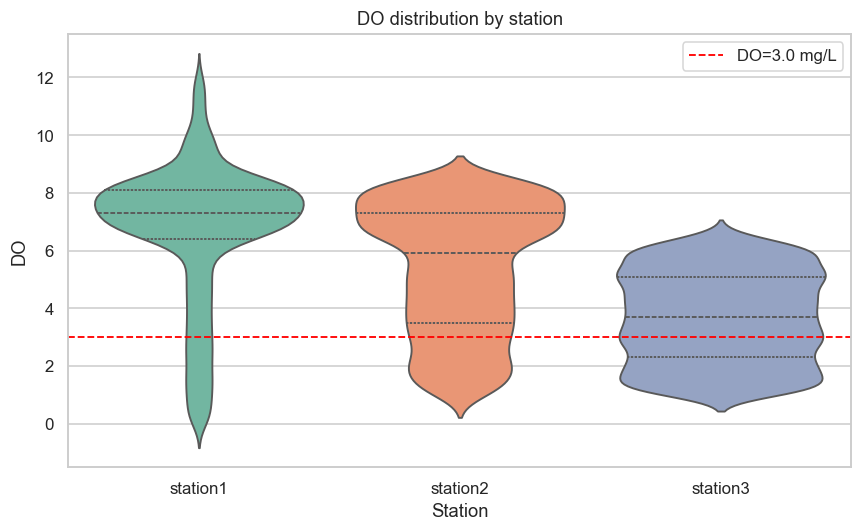

In [15]:
# DO distribution per station — violin
fig, ax = plt.subplots(figsize=(8, 5))
sns.violinplot(data=df, x='Station', y='DO', inner='quartile', palette='Set2', ax=ax)
ax.axhline(DO_THRESHOLD, color='red', linestyle='--', linewidth=1.2, label=f'DO={DO_THRESHOLD} mg/L')
ax.set_title('DO distribution by station', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

In [16]:
# Consecutive low-DO run lengths
print("=== Consecutive low-DO run lengths (readings) ===")
for stn, grp in df.groupby('Station'):
    s = grp['low_DO'].values
    runs = []
    count = 0
    for v in s:
        if v == 1:
            count += 1
        elif count > 0:
            runs.append(count)
            count = 0
    if count > 0:
        runs.append(count)
    runs = np.array(runs) if runs else np.array([0])
    print(f"\n{stn}: {len(runs)} events")
    print(f"  median={np.median(runs):.0f}  mean={runs.mean():.1f}  max={runs.max()}  p90={np.percentile(runs,90):.0f} readings")

=== Consecutive low-DO run lengths (readings) ===

station1: 1 events
  median=700  mean=700.0  max=700  p90=700 readings

station2: 808 events
  median=1  mean=1.5  max=6  p90=3 readings

station3: 1321 events
  median=1  mean=1.6  max=8  p90=3 readings


## 8. Correlations

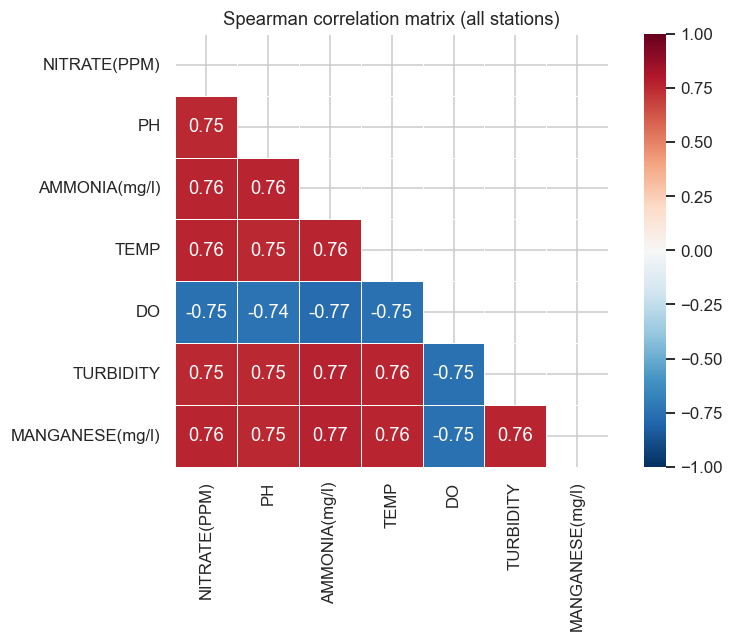


Correlations with DO:
AMMONIA(mg/l)     -0.77
NITRATE(PPM)      -0.75
TEMP              -0.75
TURBIDITY         -0.75
MANGANESE(mg/l)   -0.75
PH                -0.74
Name: DO, dtype: float64


In [17]:
corr = df[SENSORS].corr(method='spearman').round(2)

fig, ax = plt.subplots(figsize=(8, 6))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            square=True, linewidths=0.5, ax=ax, vmin=-1, vmax=1)
ax.set_title('Spearman correlation matrix (all stations)', fontsize=12)
plt.tight_layout()
plt.show()

print("\nCorrelations with DO:")
print(corr['DO'].drop('DO').sort_values(key=abs, ascending=False))

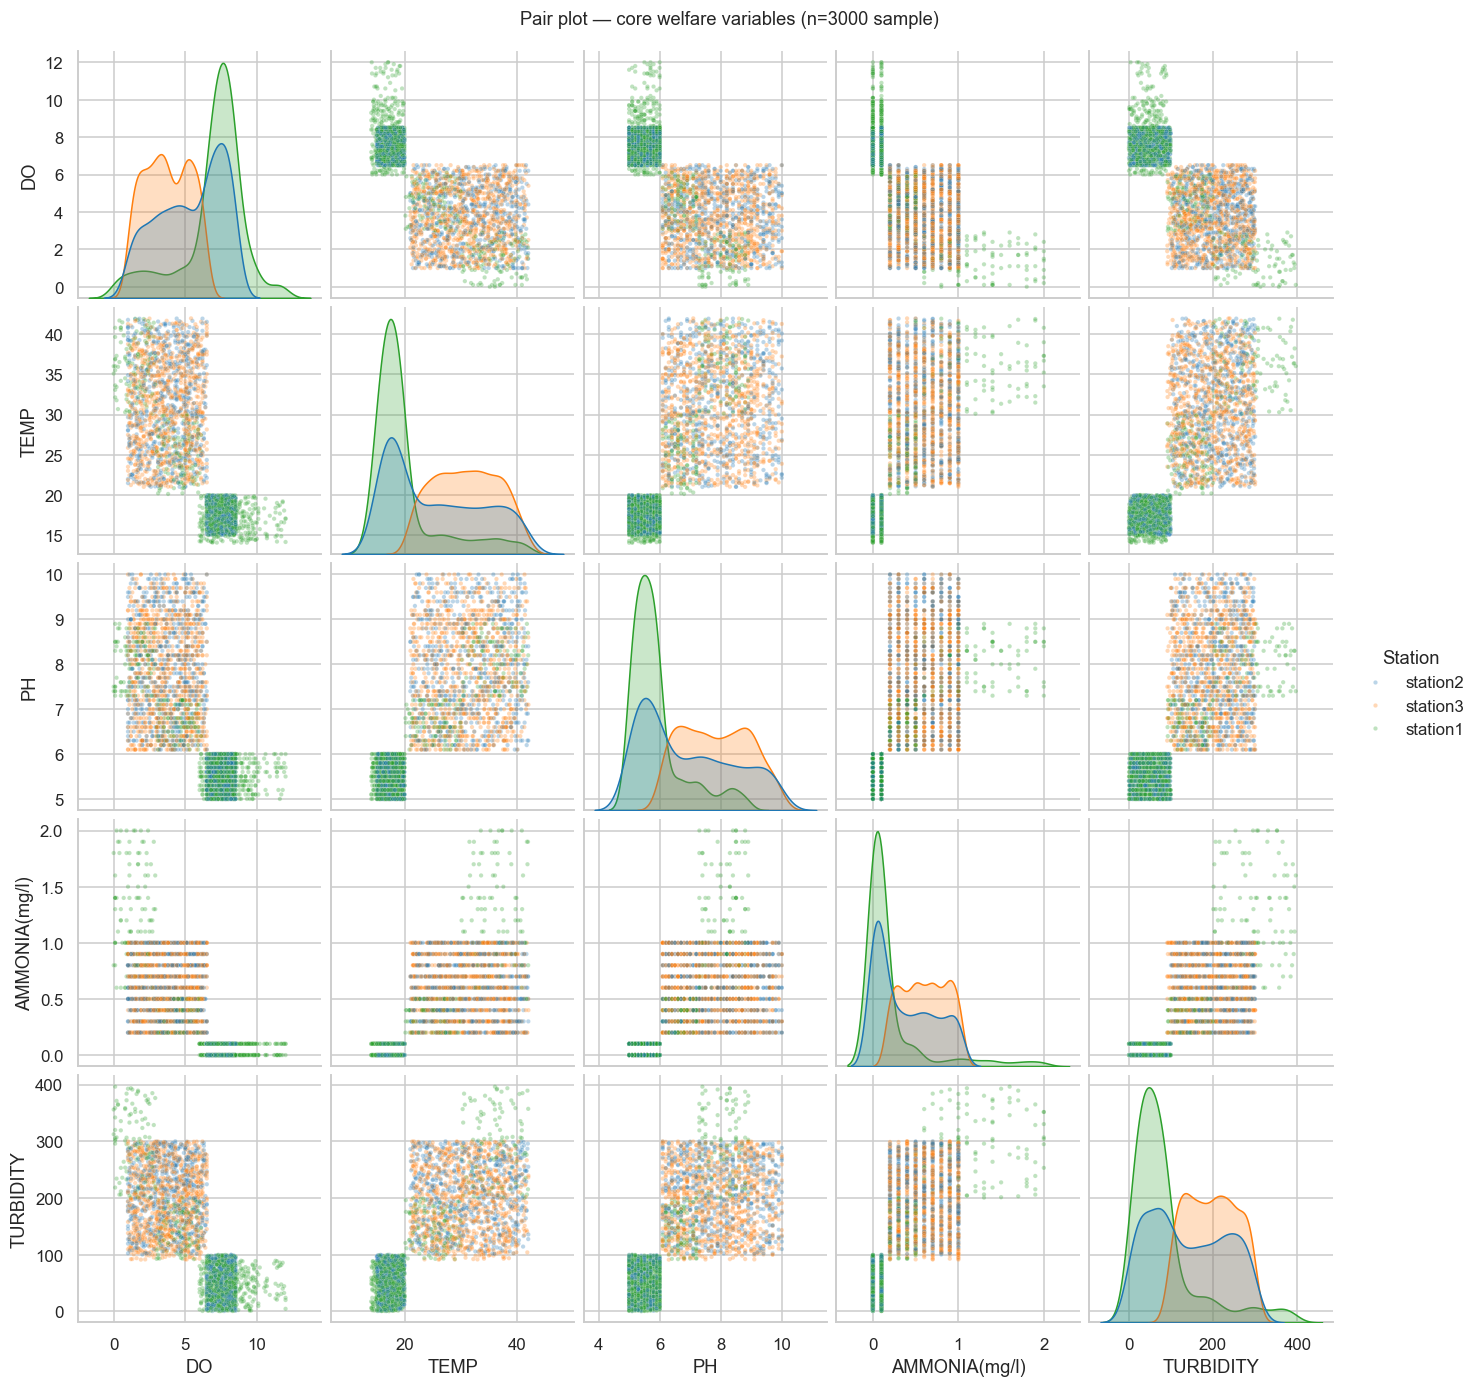

In [18]:
# Scatter matrix for core welfare variables
core = ['DO', 'TEMP', 'PH', 'AMMONIA(mg/l)', 'TURBIDITY']
sample = df[core + ['Station']].dropna().sample(n=min(3000, len(df)), random_state=42)

g = sns.pairplot(sample, hue='Station', vars=core, plot_kws={'alpha':0.3, 's':8},
                 diag_kind='kde')
g.figure.suptitle('Pair plot — core welfare variables (n=3000 sample)', y=1.01, fontsize=12)
plt.show()

## 9. Outlier analysis

In [19]:
print("=== Outliers (IQR × 1.5 rule) ===")
outlier_summary = {}
for col in SENSORS:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo_b, hi_b = q1 - 1.5*iqr, q3 + 1.5*iqr
    n_out = ((df[col] < lo_b) | (df[col] > hi_b)).sum()
    outlier_summary[col] = {'lower_fence': round(lo_b,3), 'upper_fence': round(hi_b,3),
                            'n_outliers': int(n_out), 'outlier_%': round(n_out/len(df)*100,2)}
pd.DataFrame(outlier_summary).T

=== Outliers (IQR × 1.5 rule) ===


,lower_fence,upper_fence,n_outliers,outlier_%
NITRATE(PPM),-66.050,170.350,0.0,0.00
PH,1.850,11.850,2.0,0.01
AMMONIA(mg/l),-0.800,1.600,220.0,1.22
TEMP,-3.950,54.290,0.0,0.00
DO,-3.100,13.700,0.0,0.00
TURBIDITY,-173.537,445.762,0.0,0.00
MANGANESE(mg/l),-0.540,2.740,222.0,1.23


## 10. Weekly coverage heatmap

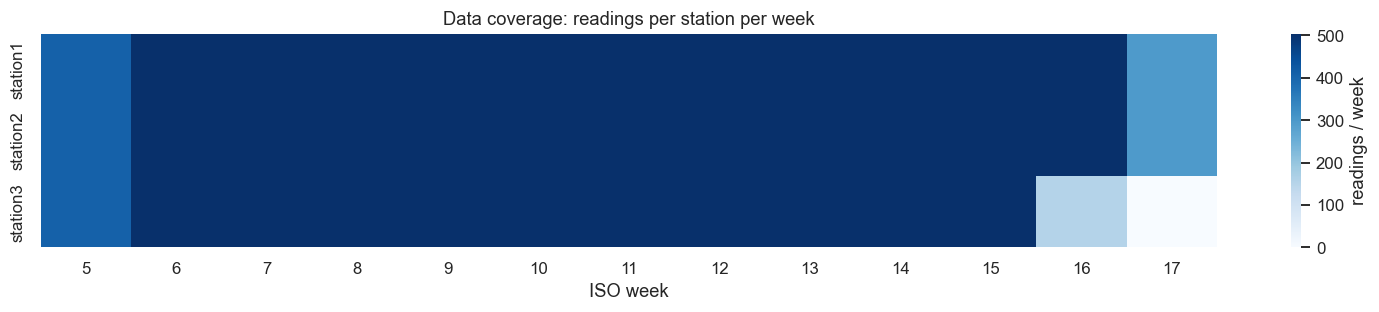

In [20]:
# Readings per station per week — data completeness
coverage = df.groupby(['Station','week']).size().unstack(level=0).fillna(0)

fig, ax = plt.subplots(figsize=(14, 3))
sns.heatmap(coverage.T, cmap='Blues', linewidths=0, ax=ax,
            cbar_kws={'label':'readings / week'})
ax.set_title('Data coverage: readings per station per week', fontsize=12)
ax.set_xlabel('ISO week')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

## 11. Summary findings

In [21]:
overall_ldo = df['low_DO'].mean()
worst_month = df.groupby('month_name')['low_DO'].mean().idxmax()
best_month  = df.groupby('month_name')['low_DO'].mean().idxmin()
peak_hour   = df.groupby('hour')['low_DO'].mean().idxmax()

print(f"Dataset: {len(df):,} readings across 3 stations, {df['date_only'].nunique()} days")
print(f"\nDO < 3 mg/L (hypoxia):")
print(f"  Overall rate       : {overall_ldo*100:.1f}%")
print(f"  Worst month        : {worst_month} ({df.groupby('month_name')['low_DO'].mean()[worst_month]*100:.1f}%)")
print(f"  Best month         : {best_month} ({df.groupby('month_name')['low_DO'].mean()[best_month]*100:.1f}%)")
print(f"  Peak hour (diurnal): {peak_hour:02d}:00")
print(f"\nDO mean / median     : {df['DO'].mean():.2f} / {df['DO'].median():.2f} mg/L")
print(f"TEMP mean            : {df['TEMP'].mean():.1f} °C")
print(f"PH mean              : {df['PH'].mean():.2f}")
print(f"AMMONIA mean         : {df['AMMONIA(mg/l)'].mean():.3f} mg/L")

Dataset: 18,102 readings across 3 stations, 88 days

DO < 3 mg/L (hypoxia):
  Overall rate       : 22.0%
  Worst month        : Feb (22.6%)
  Best month         : Mar (21.6%)
  Peak hour (diurnal): 06:00

DO mean / median     : 5.32 / 5.60 mg/L
TEMP mean            : 25.4 °C
PH mean              : 6.86
AMMONIA mean         : 0.385 mg/L
